This notebook is used for:
- reproducing the results of Harman WRR 2024;
- and training differentiable SAS-based transport model.

In [1]:
import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

import equinox as eqx

import optax

from DiffFlowTransport.transport import SASTransport
from DiffFlowTransport.sas import SAS_Gamma, SAS_Uniform, SAS_Gamma_VaryingScale
from DiffFlowTransport.sas import SAS_NormalMDN, SAS_GammaMDN, SAS_MDN
from DiffFlowTransport.utils import compute_metrics, mse, train
from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1, plot_PQET_ST, plot_PQET_quantile

import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload


# Read the data

In [2]:
df = pd.read_csv('./data.csv', index_col=1)
df.index = pd.to_datetime(df.index, format='%m/%d/%y')
df.head()

,timestep,J,Cl mg/l,Q,ET,Q Cl mg/l,S_scale
datetime,,,,,,,
1983-05-03,0,0.25,1.643836,3.404765,3.279204,NaN,4675.943543
1983-05-04,1,0.00,0.000000,3.032749,2.572585,NaN,4909.717786
1983-05-05,2,6.25,1.643836,2.954061,0.882162,NaN,4979.097380
1983-05-06,3,11.75,1.643836,3.821581,1.653902,NaN,4471.583891
1983-05-07,4,11.25,1.643836,5.064662,0.994315,NaN,3957.744963


In [3]:
J = jnp.array(df['J'].values)
Q = jnp.array(df['Q'].values)
ET = jnp.array(df['ET'].values)
C_J = jnp.array(df['Cl mg/l'].values)
C_Q_J = jnp.array(df['Q Cl mg/l'].values)


INFO:2025-02-24 15:31:31,150:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-24 15:31:31,150 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-02-24 15:31:31,151:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-02-24 15:31:31,151 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [4]:
# import jax
# import jax.numpy as jnp
# jax.scipy.stats.uniform.cdf(1.1, scale=2.2)

# Running the SAS model (w/o training)

In [5]:
# Parameters
params = {
    "dt": 1.,
    "α_Q": 1.,
    "α_ET": 0.,
    "k1": [0.],
    "C_eq": [0.],
    # "C_Q_old": [0.],
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean() / (1-0.26)]
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean() * (1-0.26)]
    # "C_Q_old": [jnp.mean(C_J * J) / Q.mean()]
    "C_Q_old": [6.]
}

# Other arguments for running the model
nt = Q.size
sTmT_init = jnp.zeros([nt, 2])


## Invariant SAS functions
Assuming $\Omega_Q$ and $\Omega_{ET}$ are the gamma and uniform distributions, separately.

In [67]:
# SAS functions
sas_Q = SAS_Gamma(a=0.53, scale=8215.)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]


In [68]:
# Initialize the SAS transport model
sas_transport = SASTransport(sas_Q, sas_ET, **params)


In [69]:
# Run the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q InvariantGamma'] = C_Q


In [10]:
# sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
# # Run the model
# sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport(
#     J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
# )
# df['C_Q 1b'] = C_Q


In [10]:
# Compute the metrics
compute_metrics(df['C_Q InvariantGamma'].values, df['Q Cl mg/l'].values, mask_naninf=True)


{'rse': 0.513252025012059,
 'mare': 0.08058608328155978,
 'rmse': 0.8599636220826388,
 'mse': 0.7395374313054915,
 'r2': -0.1314378686348041,
 'kge': 0.5633197872750567,
 'nse': 0.486747974987941,
 'mkge': 0.5746459502087302,
 'cc': 0.7108533626872132,
 'alpha': 0.9777713998848355,
 'beta': 0.6888309476482889}

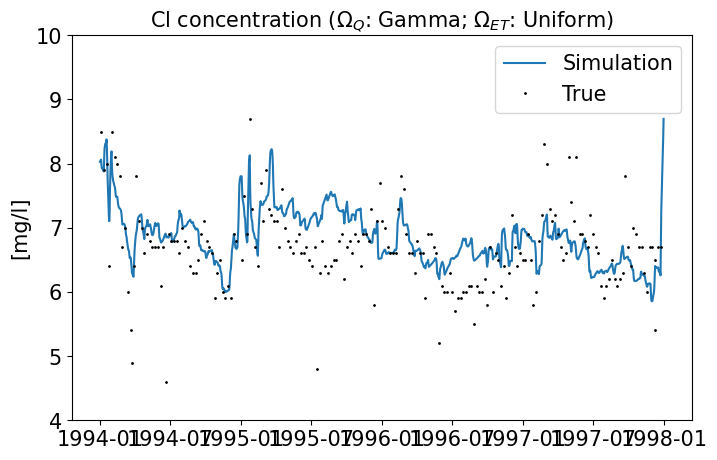

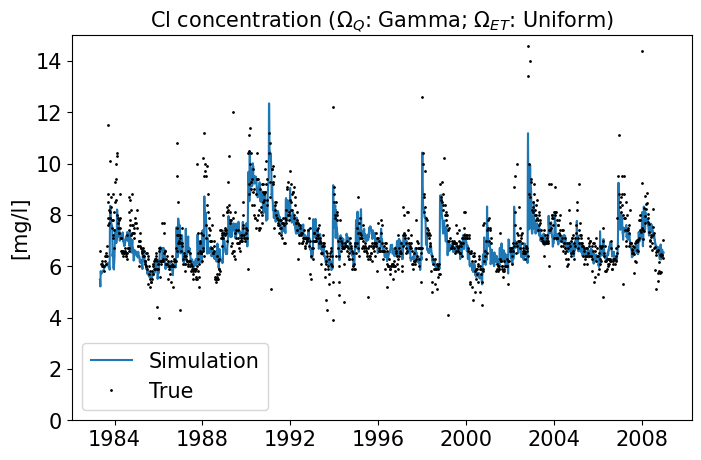

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q InvariantGamma']["1994":"1997"], label='Simulation')
ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q InvariantGamma'], label='Simulation')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


array([<Axes: title={'center': 'Q age distribution'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution'}, ylabel='Age [Days]'>],
      dtype=object)

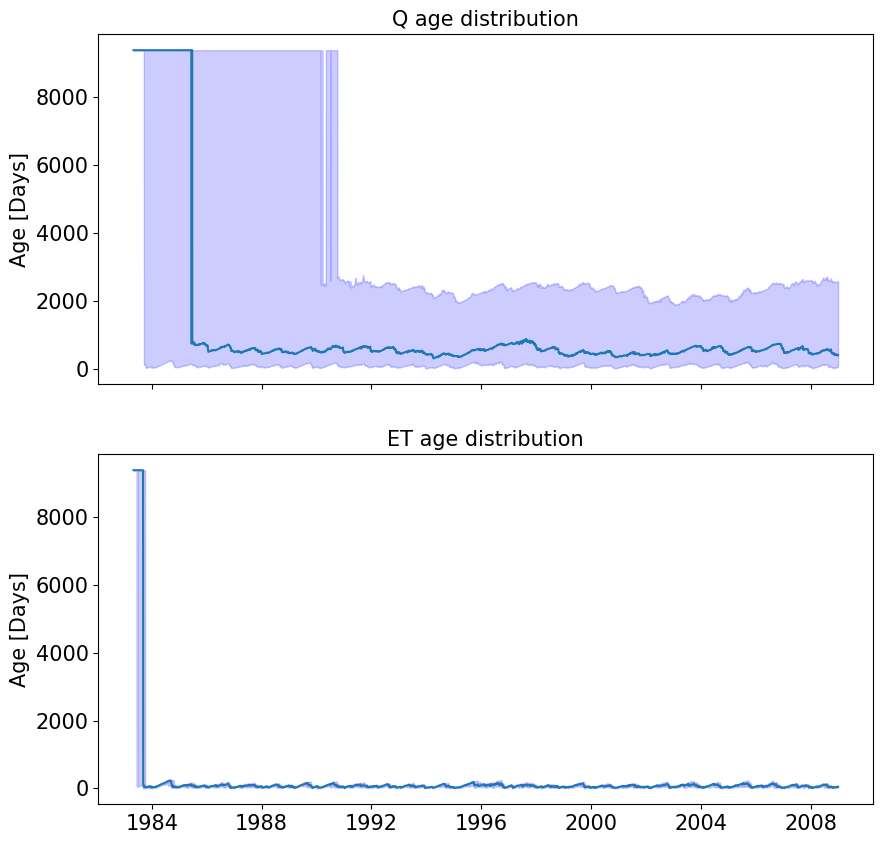

In [70]:
plot_PQET_quantile(pQETs, params['dt'], df.index)


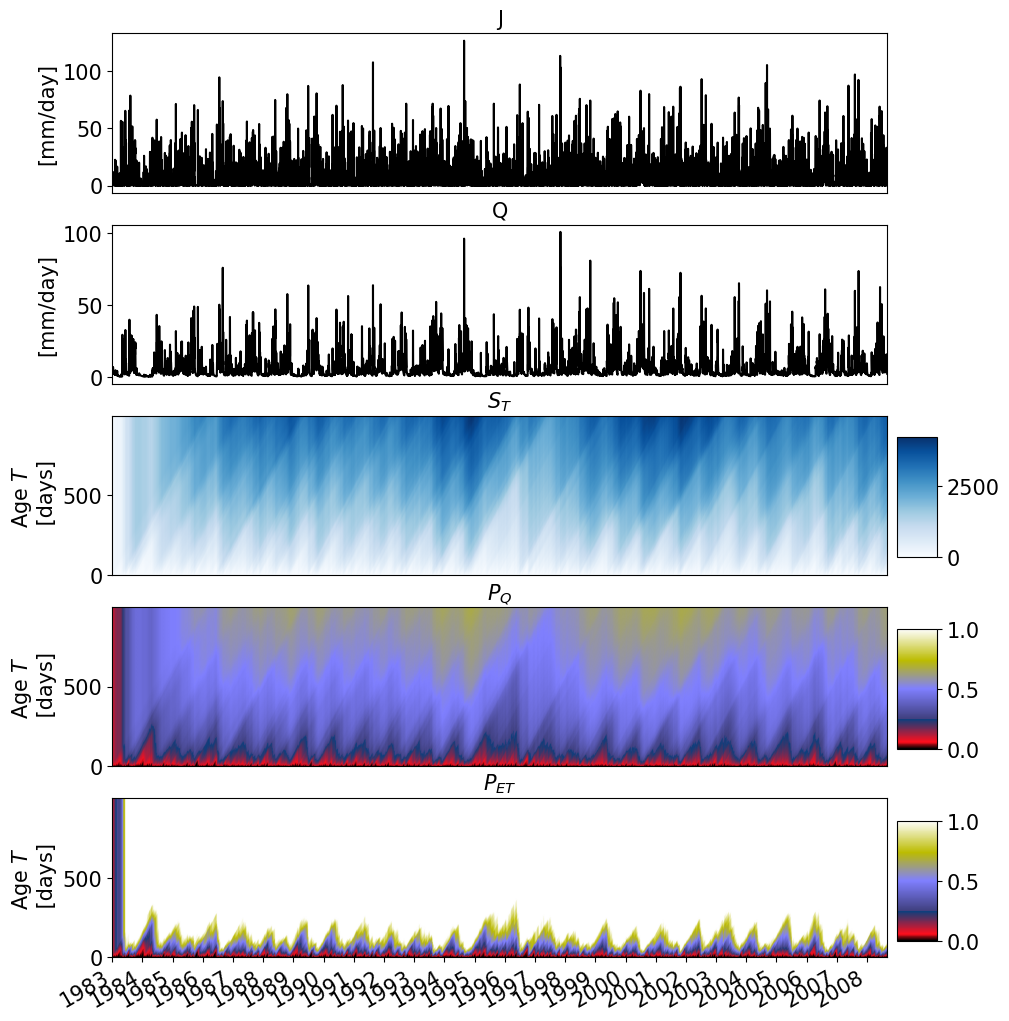

In [12]:
plot_PQET_ST(
    df['J'].values, df['Q'].values, sT, pQETs,
    params['dt'], df.index, age_cut=1000
)

In [13]:
# plt.imshow(pQETs[...,0], cmap='Blues', vmin=0., vmax=0.005)
# plt.colorbar()
# # plt.plot(pQETs[:,900,0])
# # plt.imshow(sT, cmap='Blues')
# # plt.colorbar()

In [13]:
# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 1']["1994":"1997"], label='Simulation A (no spinup)')
# ax.plot(df['C_Q 1b']["1994":"1997"], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
# ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 1'], label='Simulation A (no spinup)')
# ax.plot(df['C_Q 1b'], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
# ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()


## Storage dependent SAS

In [63]:
# SAS functions
sas_Q = SAS_Gamma_VaryingScale(a=0.69, scale=8215.)
sas_ET = SAS_Uniform(scale=398.)

# SAS arguments 
# sas_Q_args = jnp.array(df['S_scale'].values[:,None])
sas_Q_args = jnp.array(df['S_scale'].values)
sas_ET_args = ET


In [64]:
# Initialize the SAS transport model
sas_transport2 = SASTransport(sas_Q, sas_ET, **params)

In [65]:
# Run the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q VariantGamma'] = C_Q


In [16]:
# # Rerun the model
# sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
# sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
#     J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
# )
# df['C_Q 2b'] = C_Q

In [17]:
# Compute the metrics
compute_metrics(df['C_Q VariantGamma'].values, df['Q Cl mg/l'].values, mask_naninf=True)


{'rse': 0.38592973753363946,
 'mare': 0.07228956798942643,
 'rmse': 0.7457081103589498,
 'mse': 0.5560805858551157,
 'r2': 0.3102950449283872,
 'kge': 0.6686304154177074,
 'nse': 0.6140702624663605,
 'mkge': 0.6708110679719194,
 'cc': 0.784813478690066,
 'alpha': 0.9961715401658138,
 'beta': 0.7509107450900067}

(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Cl ($\\Omega_Q$: Storage-dependent Gamma; $\\Omega_{ET}$: Invariant Uniform)'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 0.746; NSE: 0.614)'}, xlabel='Observation', ylabel='Simulation'>)

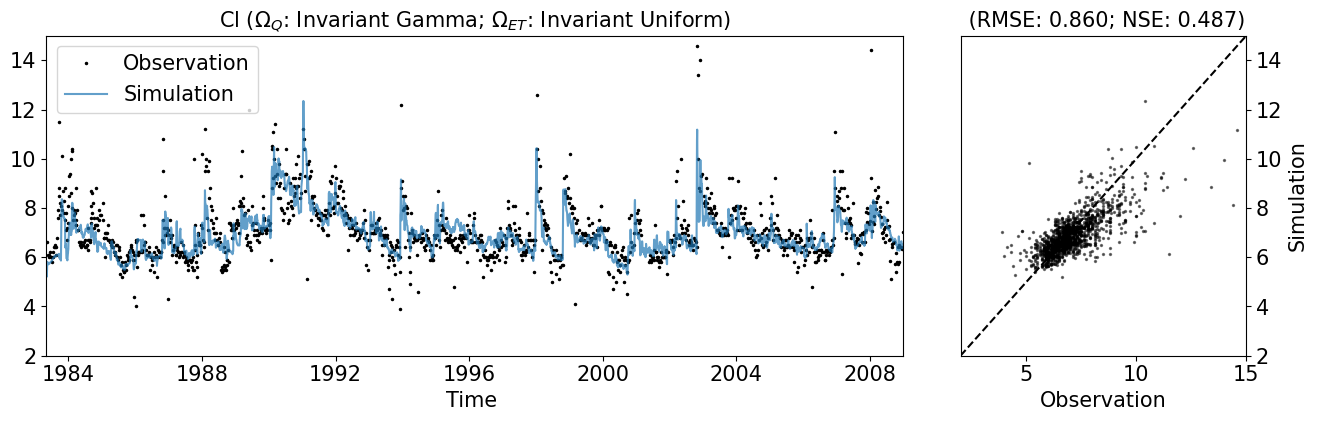

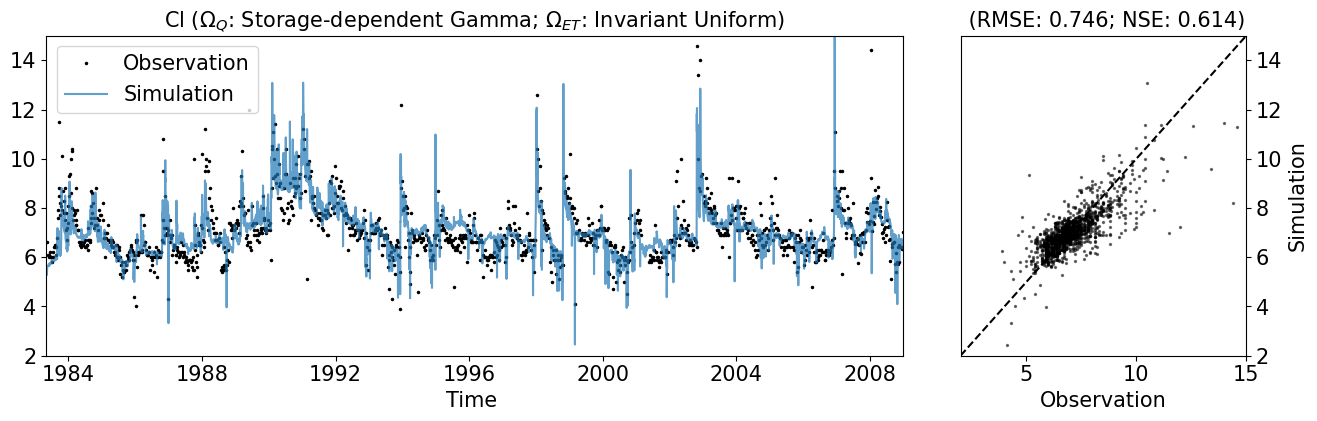

In [29]:
# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q VariantGamma'], label='Simulation')
# ax.plot(df['C_Q InvariantGamma'], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
# ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q InvariantGamma'].values, lim=[2,15], 
    timesteps=df.index,
    varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q VariantGamma'].values, lim=[2,15], 
    timesteps=df.index,
    varn='Cl ($\Omega_Q$: Storage-dependent Gamma; $\Omega_{ET}$: Invariant Uniform)'
)


array([<Axes: title={'center': 'Q age distribution'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution'}, ylabel='Age [Days]'>],
      dtype=object)

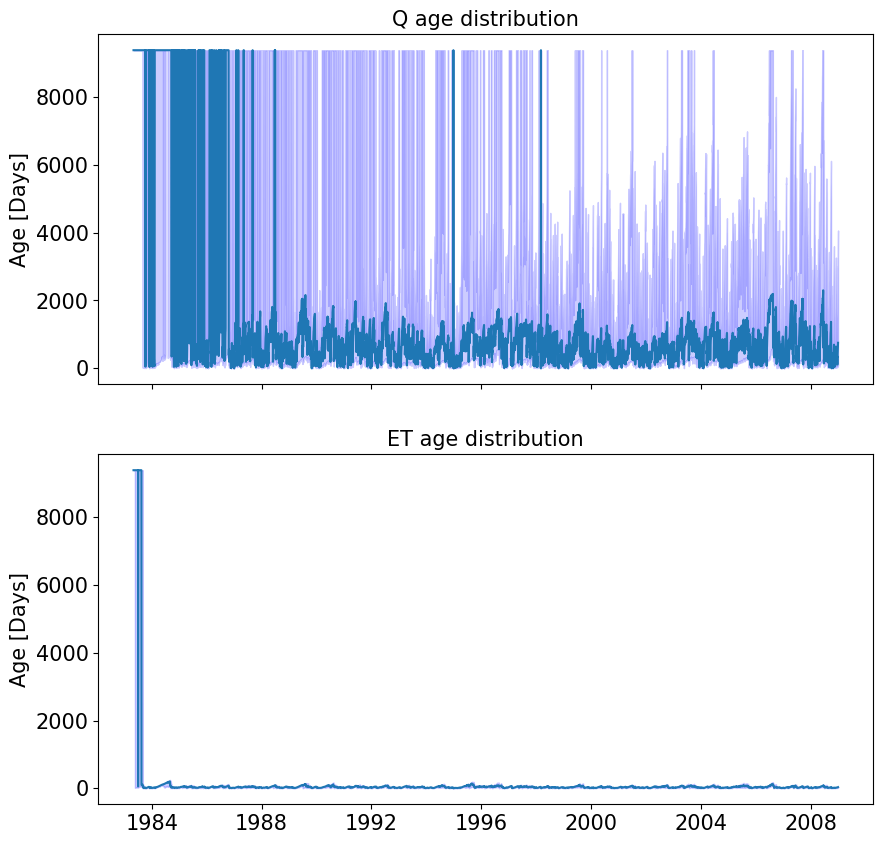

In [66]:
plot_PQET_quantile(pQETs, params['dt'], df.index)


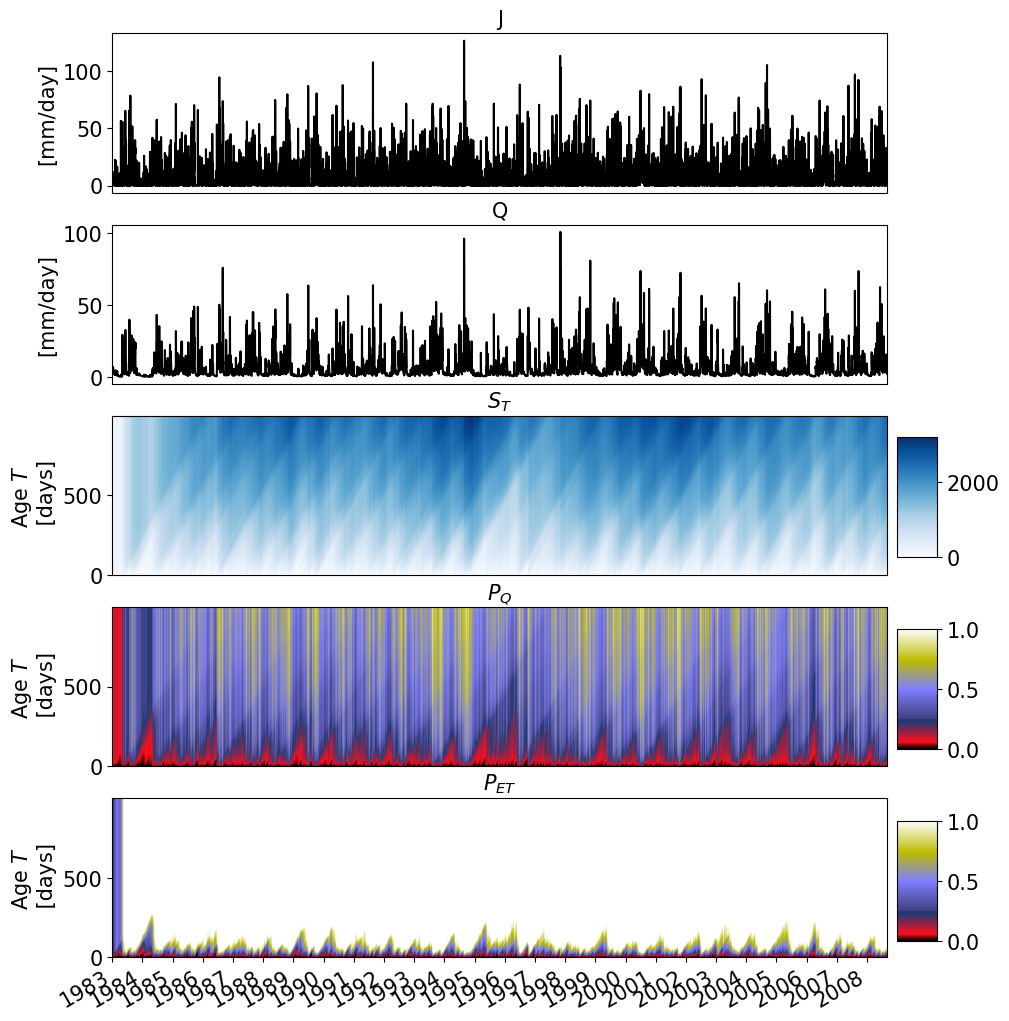

In [18]:
plot_PQET_ST(
    df['J'].values, df['Q'].values, sT, pQETs,
    params['dt'], df.index, age_cut=1000
)


In [20]:
# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 2']["1994":"1997"], label='Simulation A (no spinup)')
# ax.plot(df['C_Q 2b']["1994":"1997"], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
# ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()


# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 2'], label='Simulation')
# # ax.plot(df['C_Q 2'], label='Simulation A (no spinup)')
# # ax.plot(df['C_Q 2b'], alpha=0.7, label='Simulation B (using A as spinup)')
# ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
# ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()


## MDN-based SAS

In [149]:
# SAS functions
n_input, n_hidden, n_mixture, key = 1, 20, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 20, "depth":3}
sas_Q = SAS_MDN(n_input, n_hidden, n_mixture, key, scale=8215, **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]


In [66]:
# Initialize the SAS transport model
sas_transport2 = SASTransport(sas_Q, sas_ET, **params)

In [68]:
# Spinup the model
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 2'] = C_Q

In [69]:
# Rerun the model
sTmT_init2 = jnp.concat([sT[:,-1,None], mT[:,-1,:]], axis=-1)
sT, mT, mQETs, pQETs, mRs, C_Q = sas_transport2(
    J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
)
df['C_Q 2b'] = C_Q

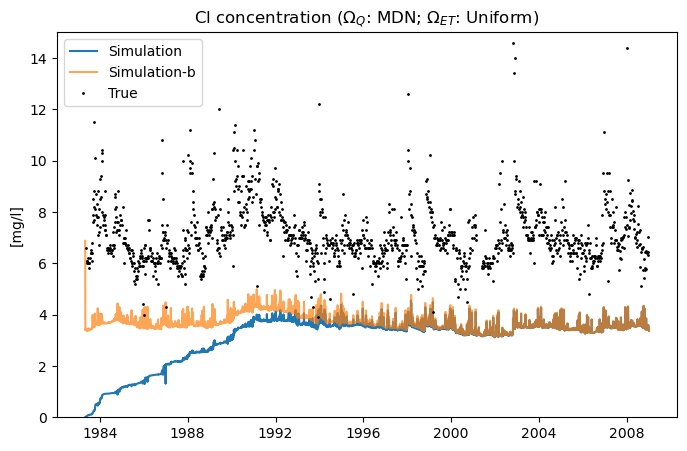

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 2'], label='Simulation')
ax.plot(df['C_Q 2b'], alpha=0.7, label='Simulation-b')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[0, 15], title='Cl concentration ($\Omega_Q$: MDN; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


# Training the SAS-based transport model

In [6]:
# Training parameters
epochs = 100
loss_func = mse
optim = optax.adam(learning_rate=0.01)

In [7]:
# Separate training and test sets
start_train, end_train = '1989-01-01', '1998-12-31'
start_test, end_test = '1999-01-01', '2008-12-31'

start_train_ind = df.index.get_loc(start_train)
end_train_ind = df.index.get_loc(end_train)
start_test_ind = df.index.get_loc(start_test)
end_test_ind = df.index.get_loc(end_test)


## Invariant SAS functions

In [8]:
# SAS functions
sas_Q = SAS_Gamma(a=0.53, scale=8215.)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model = SASTransport(sas_Q, sas_ET, **params)


In [9]:
filter_model_spec = jtu.tree_map(lambda _: False, model)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
sas_Q_filter = eqx.tree_at(lambda t: (t.loc,), sas_Q_filter, replace=(False,))
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [10]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>start_train_ind) & (mask[0]<end_train_ind)]
# x_train = [J[:end_train_ind], C_J[:end_train_ind], Q[:end_train_ind], ET[:end_train_ind], 
#            sTmT_init[:end_train_ind], sas_Q_args[:end_train_ind], sas_ET_args[:end_train_ind], mask_train]
x_train = [e[:end_train_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>start_test_ind) & (mask[0]<end_test_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((520, 1), (492, 1))

In [12]:
model_new, loss_train, loss_test = train(
    model.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x_train, y_train, x_test, y_test
)


100%|██████████| 10/10 [13:04<00:00, 78.47s/it]


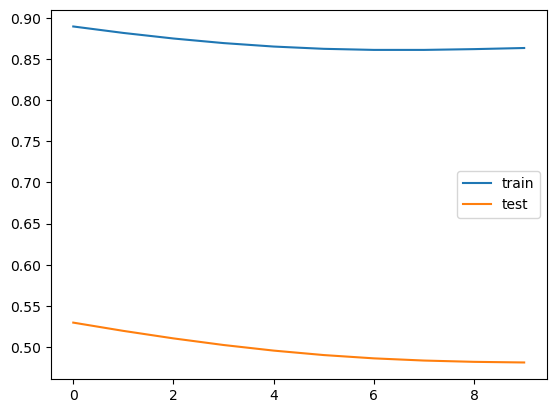

In [26]:
# Plot the loss
plt.plot(loss_train, label='train')
plt.plot(loss_test, label='test')
plt.legend()

In [13]:
# Run the trained model
model_new = model_new.__self__
sT, mT, mQETs, pQETs, mRs, C_Q = model_new(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 1-trained'] = C_Q

# Run the untrained model
sT, mT, mQETs, pQETs, mRs, C_Q = model(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q 1'] = C_Q


In [20]:
# metrics = compute_metrics(df['C_Q 1-trained'].values, df['Q Cl mg/l'].values, mask_naninf=True)


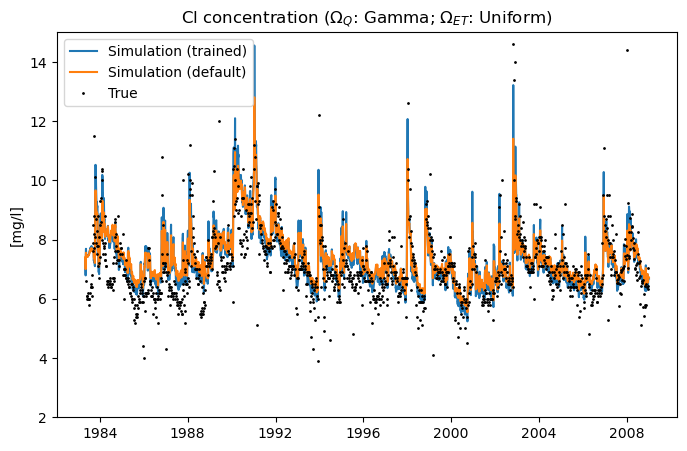

In [17]:
# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(df['C_Q 1-trained']["1994":"1997"], label='Simulation A (no spinup)')
# ax.plot(df['Q Cl mg/l']["1994":"1997"], 'k.', markersize=2, label='True')
# ax.set(ylim=[4, 10], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
#        ylabel='[mg/l]')
# ax.legend()

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(df['C_Q 1-trained'], label='Simulation (trained)')
ax.plot(df['C_Q 1'], label='Simulation (default)')
ax.plot(df['Q Cl mg/l'], 'k.', markersize=2, label='True')
ax.set(ylim=[2, 15], title='Cl concentration ($\Omega_Q$: Gamma; $\Omega_{ET}$: Uniform)', 
       ylabel='[mg/l]')
ax.legend()


## MDN Gaussian-based SAS

In [8]:
# SAS functions
n_input, n_hidden, n_mixture, key = 1, 10, 5, 42
mlp_kwargs = {"width_size": 10, "depth":2}
sas_Q = SAS_NormalMDN(n_input, n_hidden, n_mixture, key, scale=8215., **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model_mdn = SASTransport(sas_Q, sas_ET, **params)


In [9]:
filter_model_spec = jtu.tree_map(lambda _: False, model_mdn)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
# sas_Q_filter = eqx.tree_at(lambda t: (t.loc,), sas_Q_filter, replace=(False,))
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [10]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>start_train_ind) & (mask[0]<end_train_ind)]
# x_train = [J[:end_train_ind], C_J[:end_train_ind], Q[:end_train_ind], ET[:end_train_ind], 
#            sTmT_init[:end_train_ind], sas_Q_args[:end_train_ind], sas_ET_args[:end_train_ind], mask_train]
x_train = [e[:end_train_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>start_test_ind) & (mask[0]<end_test_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((520, 1), (492, 1))

In [11]:
# Train the model
jax.clear_caches()
model_mdn_new, loss_train_mdn, loss_test_mdn = train(
    model_mdn.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x_train, y_train, x_test, y_test
)
model_mdn_new = model_mdn_new.__self__


2025-02-10 15:17:46,688 - INFO - The loss of step 0: 2.643779754638672
2025-02-10 15:18:17,695 - INFO - The loss of step 1: 2.2693397998809814
2025-02-10 15:18:36,960 - INFO - The loss of step 2: 1.7491490840911865
2025-02-10 15:18:44,470 - INFO - The loss of step 3: 1.4657827615737915
2025-02-10 15:18:51,983 - INFO - The loss of step 4: 1.2134586572647095
2025-02-10 15:18:59,480 - INFO - The loss of step 5: 1.157802700996399
2025-02-10 15:19:06,995 - INFO - The loss of step 6: 1.1343361139297485
2025-02-10 15:19:14,501 - INFO - The loss of step 7: 1.0862805843353271
2025-02-10 15:19:22,014 - INFO - The loss of step 8: 1.0395106077194214
2025-02-10 15:19:29,522 - INFO - The loss of step 9: 0.9816726446151733
2025-02-10 15:19:37,048 - INFO - The loss of step 10: 0.952201783657074
2025-02-10 15:19:44,550 - INFO - The loss of step 11: 0.964239239692688
2025-02-10 15:19:52,051 - INFO - The loss of step 12: 0.9300936460494995
2025-02-10 15:19:59,552 - INFO - The loss of step 13: 0.912895262

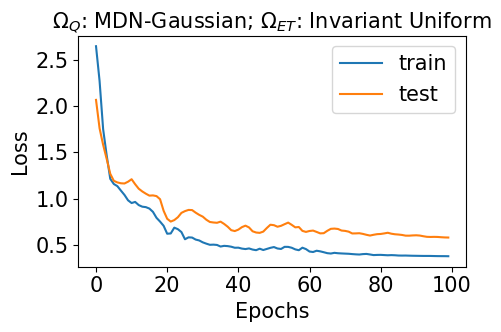

In [12]:
# Plot the loss
fig, ax = plt.subplots(1, 1, figsize=(5,3))
ax.plot(loss_train_mdn, label='train')
ax.plot(loss_test_mdn, label='test')
ax.set(xlabel='Epochs', ylabel='Loss', 
       title='$\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform')
ax.legend()


In [13]:
# Run the trained model
# 
sT, mT, mQETs, pQETs, mRs, C_Q = model_mdn_new(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q mdn-trained'] = C_Q

# # Run the untrained model
# sT, mT, mQETs, pQETs, mRs, C_Q = model_mdn(
#     J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
# )
# # plt.plot(C_Q)
# df['C_Q mdn'] = C_Q


array([<Axes: title={'center': 'Q age distribution'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution'}, ylabel='Age [Days]'>],
      dtype=object)

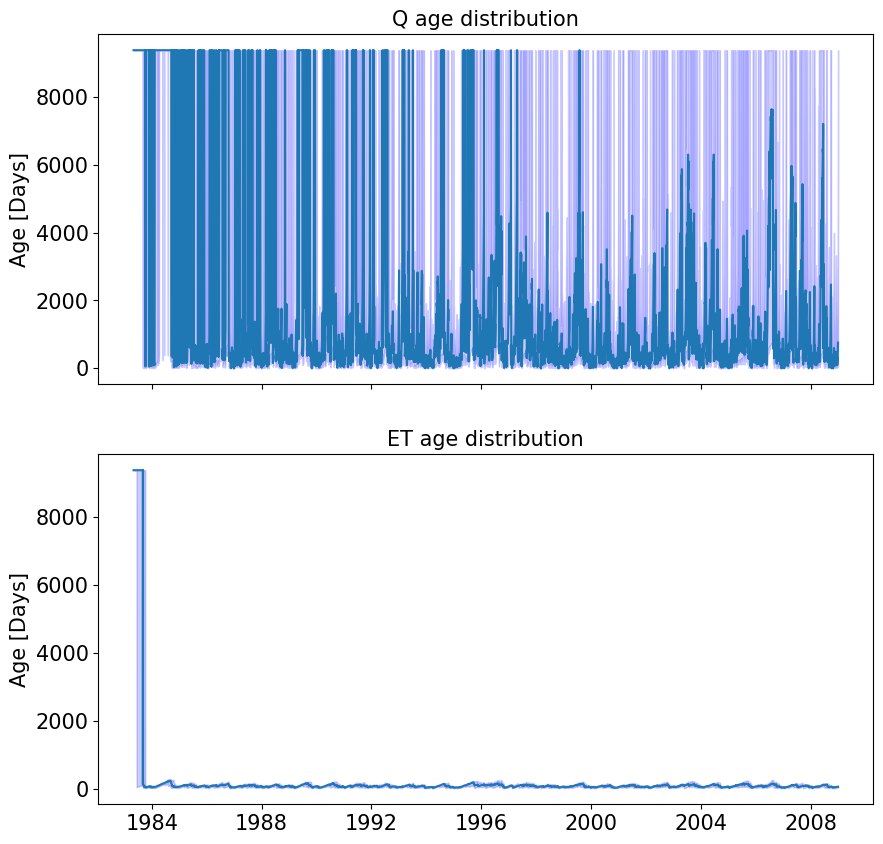

In [62]:
plot_PQET_quantile(pQETs, params['dt'], df.index)


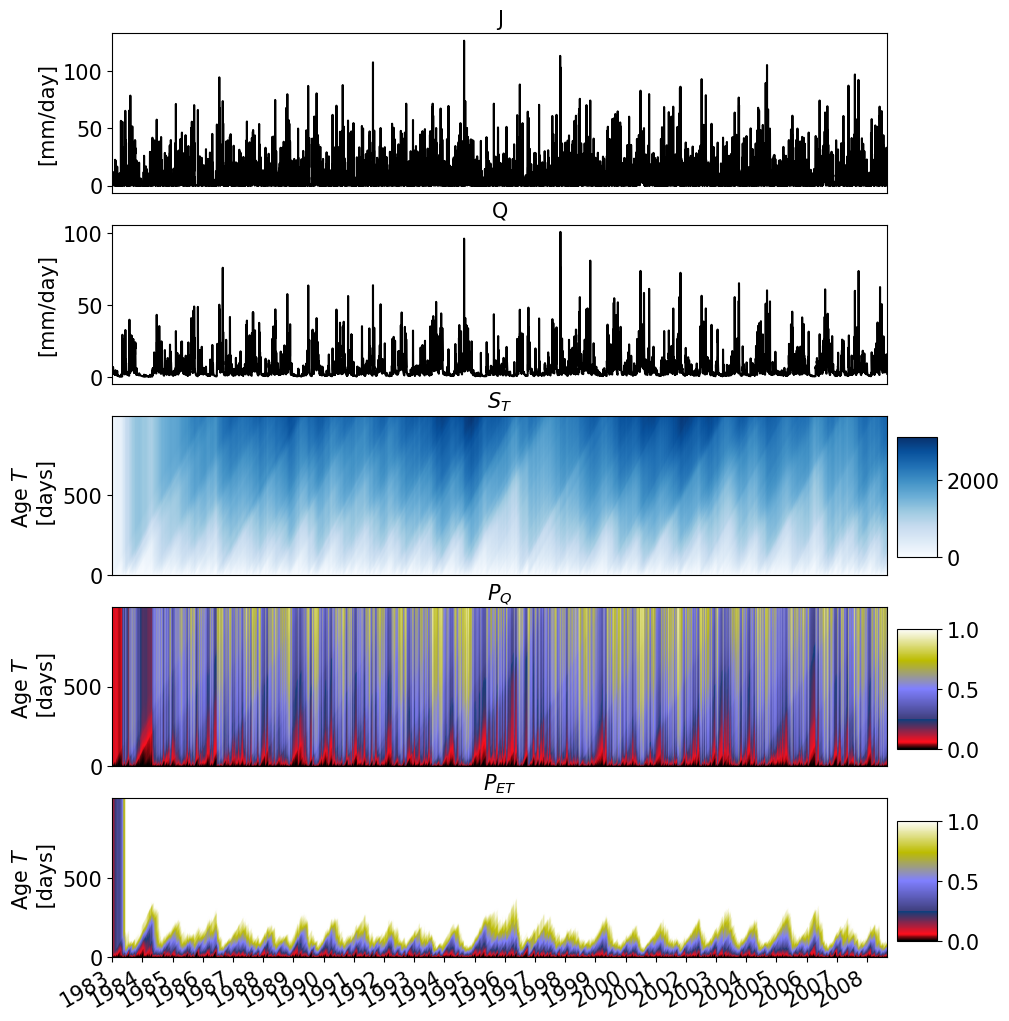

In [14]:
plot_PQET_ST(
    df['J'].values, df['Q'].values, sT, pQETs,
    params['dt'], df.index, age_cut=1000
)


In [15]:
# Compute the metrics
compute_metrics(df['C_Q mdn-trained'].values, df['Q Cl mg/l'].values, mask_naninf=True)


{'rse': 0.383598086840709,
 'mare': 0.07164641194053875,
 'rmse': 0.7434520455560693,
 'mse': 0.5527209440415036,
 'r2': 0.4397869687127176,
 'kge': 0.7378933496197065,
 'nse': 0.616401913159291,
 'mkge': 0.7539188609325769,
 'cc': 0.8049445154786109,
 'alpha': 0.9701201739134424,
 'beta': 0.8529745567737215}

(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Cl ($\\Omega_Q$: Variant Gamma; $\\Omega_{ET}$: Invariant Uniform)'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 0.746; NSE: 0.614)'}, xlabel='Observation', ylabel='Simulation'>)

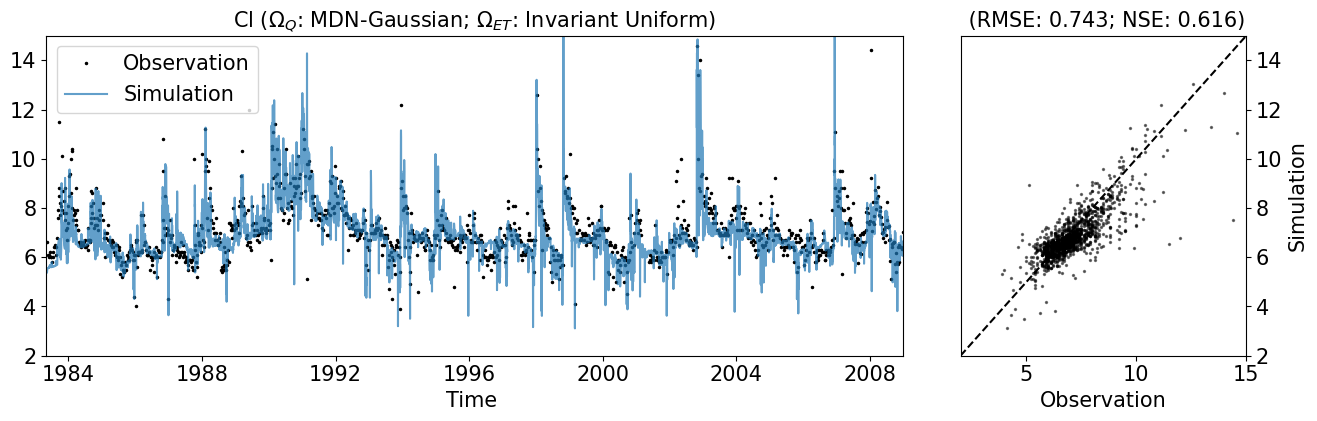

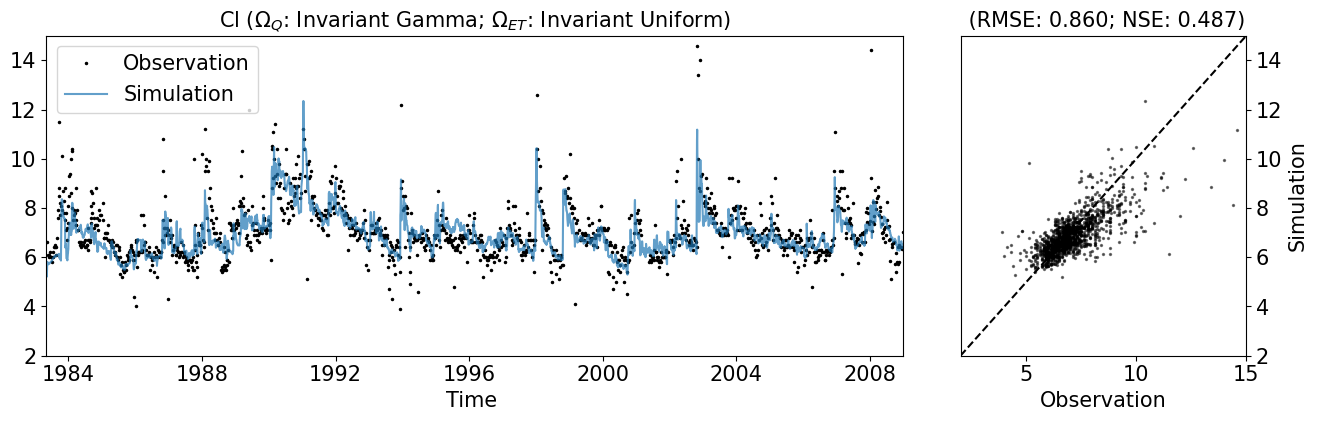

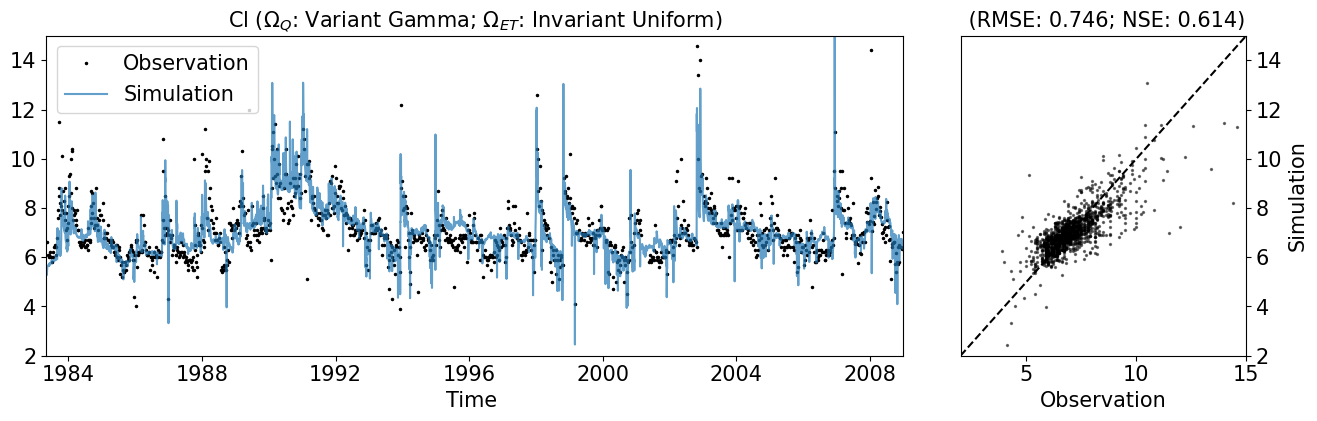

In [71]:
plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q mdn-trained'].values, lim=[2,15], timesteps=df.index,
    varn='Cl ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q InvariantGamma'].values, lim=[2,15], timesteps=df.index,
    varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q VariantGamma'].values, lim=[2,15], timesteps=df.index,
    varn='Cl ($\Omega_Q$: Variant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)


(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Cl ($\\Omega_Q$: Variant Gamma; $\\Omega_{ET}$: Invariant Uniform)'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 0.705; NSE: 0.603)'}, xlabel='Observation', ylabel='Simulation'>)

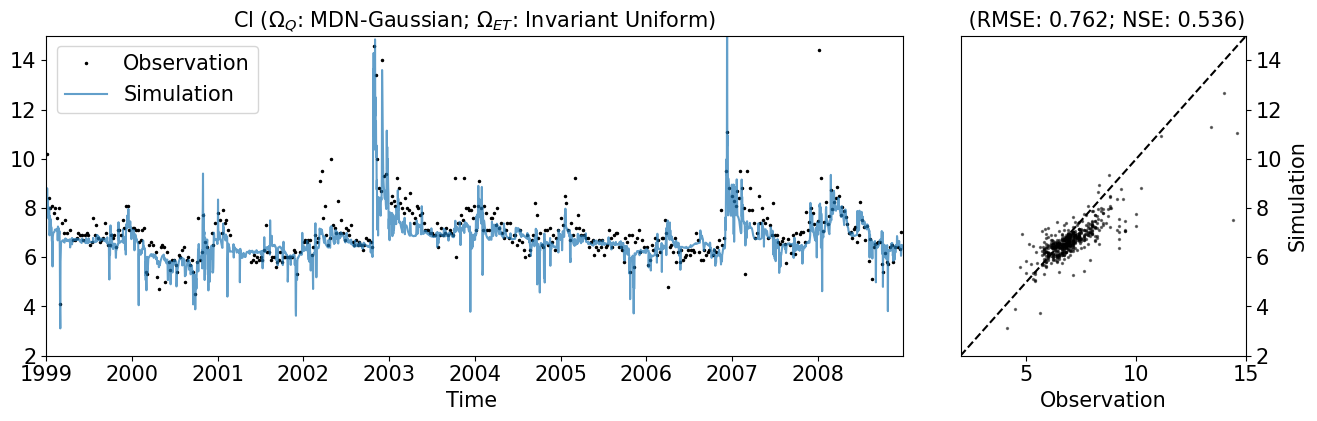

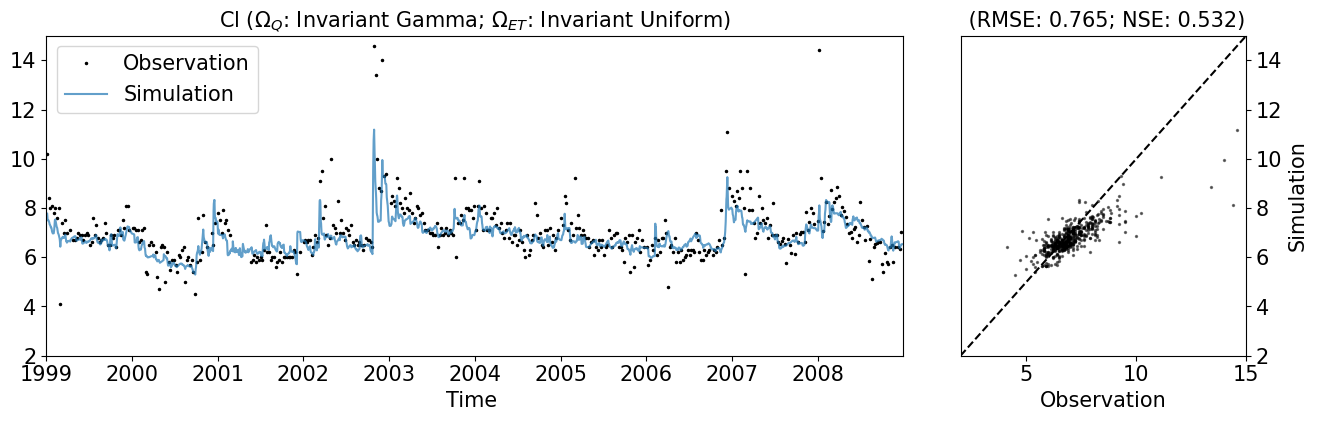

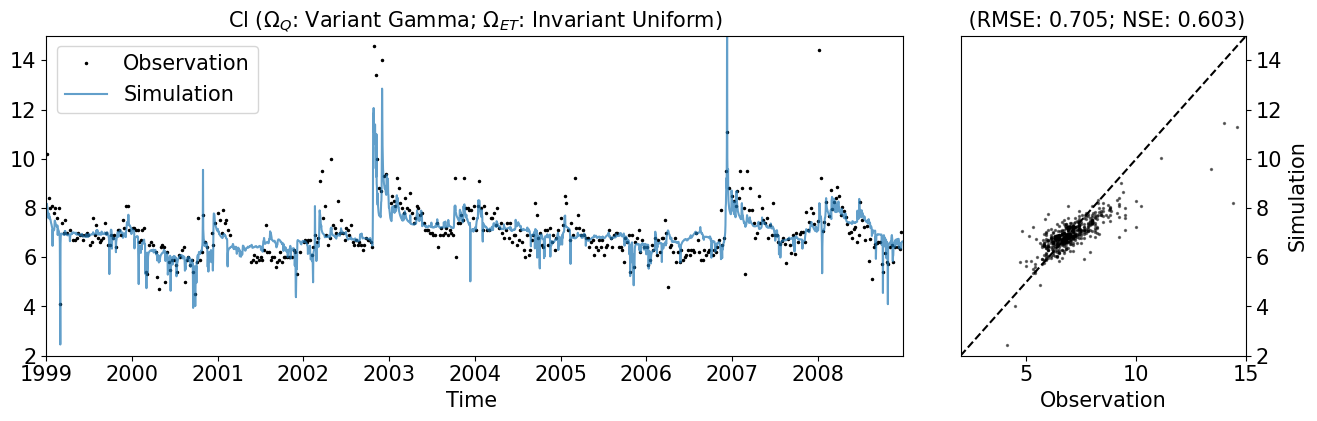

In [40]:
# s, e = '1988', '1992'
s, e = start_test, end_test
plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'][s:e].values, sim=df['C_Q mdn-trained'][s:e].values, lim=[2,15], 
    timesteps=df[s:e].index,
    varn='Cl ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'][s:e].values, sim=df['C_Q InvariantGamma'][s:e].values, lim=[2,15], 
    timesteps=df[s:e].index,
    varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'][s:e].values, sim=df['C_Q VariantGamma'][s:e].values, lim=[2,15], 
    timesteps=df[s:e].index,
    varn='Cl ($\Omega_Q$: Variant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)


## MDN Gamma-based SAS

In [8]:
# SAS functions
n_input, n_hidden, n_mixture, key = 1, 5, 2, 42
mlp_kwargs = {"width_size": 5, "depth":2}
sas_Q = SAS_GammaMDN(n_input, n_hidden, n_mixture, key, scale=8215., **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model_mdn_gamma = SASTransport(sas_Q, sas_ET, **params)


In [9]:
filter_model_spec = jtu.tree_map(lambda _: False, model_mdn_gamma)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
# sas_Q_filter = eqx.tree_at(lambda t: (t.loc,), sas_Q_filter, replace=(False,))
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [10]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>start_train_ind) & (mask[0]<end_train_ind)]
# x_train = [J[:end_train_ind], C_J[:end_train_ind], Q[:end_train_ind], ET[:end_train_ind], 
#            sTmT_init[:end_train_ind], sas_Q_args[:end_train_ind], sas_ET_args[:end_train_ind], mask_train]
x_train = [e[:end_train_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>start_test_ind) & (mask[0]<end_test_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((520, 1), (492, 1))

In [ ]:
# Train the model
jax.clear_caches()
model_mdn_gamma_new, loss_train_mdn_gamma, loss_test_mdn_gamma = train(
    model_mdn_gamma.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x_train, y_train, x_test, y_test
)


In [ ]:
# Plot the loss
fig, ax = plt.subplots(1, 1, figsize=(5,3))
ax.plot(loss_train_mdn, label='train')
ax.plot(loss_test_mdn, label='test')
ax.set(xlabel='Epochs', ylabel='Loss', 
       title='$\Omega_Q$: MDN-Gamma; $\Omega_{ET}$: Invariant Uniform')
ax.legend()


In [ ]:
# Run the trained model
# 
sT, mT, mQETs, pQETs, mRs, C_Q = model_mdn_gamma_new(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
# plt.plot(C_Q)
df['C_Q mdn-gamma-trained'] = C_Q


In [ ]:
plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q mdn-gamma-trained'].values, lim=[2,15], timesteps=df.index,
    varn='Cl ($\Omega_Q$: MDN-Gamma; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q InvariantGamma'].values, lim=[2,15], timesteps=df.index,
    varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'].values, sim=df['C_Q VariantGamma'].values, lim=[2,15], timesteps=df.index,
    varn='Cl ($\Omega_Q$: Variant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)


In [ ]:
# s, e = '1988', '1992'
s, e = start_test, end_test
plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'][s:e].values, sim=df['C_Q mdn-gamma-trained'][s:e].values, lim=[2,15], 
    timesteps=df[s:e].index,
    varn='Cl ($\Omega_Q$: MDN-Gamma; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'][s:e].values, sim=df['C_Q InvariantGamma'][s:e].values, lim=[2,15], 
    timesteps=df[s:e].index,
    varn='Cl ($\Omega_Q$: Invariant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)

plot_timeseries_obs_1to1(
    obs=df['Q Cl mg/l'][s:e].values, sim=df['C_Q VariantGamma'][s:e].values, lim=[2,15], 
    timesteps=df[s:e].index,
    varn='Cl ($\Omega_Q$: Variant Gamma; $\Omega_{ET}$: Invariant Uniform)'
)


## MDN-based SAS

In [8]:
# SAS functions
n_input, n_hidden, key = 1, 2, 42
mlp_kwargs = {"width_size": 5, "depth":2}
sas_Q = SAS_MDN(n_input, n_hidden, key, scale=8215., **mlp_kwargs)
sas_ET = SAS_Uniform(scale=737.)

# SAS arguments 
sas_Q_args = Q[:,None]
sas_ET_args = ET[:,None]

# Initialize the SAS transport model
model_mdn = SASTransport(sas_Q, sas_ET, **params)


In [9]:
filter_model_spec = jtu.tree_map(lambda _: False, model_mdn)
sas_Q_filter = jtu.tree_map(lambda _: True, sas_Q)
sas_ET_filter = jtu.tree_map(lambda _: True, sas_ET)
sas_ET_filter = eqx.tree_at(lambda t: (t.loc,), sas_ET_filter, replace=(False,))
filter_model_spec = eqx.tree_at(lambda t: (t.sas_Q, t.sas_ET), filter_model_spec, replace=(sas_Q_filter, sas_ET_filter))


In [10]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>start_train_ind) & (mask[0]<end_train_ind)]
# x_train = [J[:end_train_ind], C_J[:end_train_ind], Q[:end_train_ind], ET[:end_train_ind], 
#            sTmT_init[:end_train_ind], sas_Q_args[:end_train_ind], sas_ET_args[:end_train_ind], mask_train]
x_train = [e[:end_train_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>start_test_ind) & (mask[0]<end_test_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((520, 1), (492, 1))

In [11]:
# Train the model
jax.clear_caches()
model_mdn_new, loss_train_mdn, loss_test_mdn = train(
    model_mdn.get_CQ, filter_model_spec.get_CQ,
    epochs, loss_func, optim, x_train, y_train, x_test, y_test
)
model_mdn_new = model_mdn_new.__self__


2025-02-24 15:33:14,194 - INFO - The loss of step 0: 1.2491521835327148
2025-02-24 15:35:54,875 - INFO - The loss of step 1: 1.1820471286773682
  2%|▏         | 2/100 [05:31<4:30:33, 165.65s/it]


KeyboardInterrupt: 